***GROUP 12 MEMBERS***
* **JUMA CLINI BENSON      SCT213-C002-0120/2024**
* **MILANETTO DANIEL       SCT213-C002-0010/2024**
* **ABDULLAHI YUSSUF       SCT213-C002-0132/2024**
* **MIKE GITONGA           SCT213-C002-0011/2024**
* **AHMED IBRAHIM          SCT213-C002-0100/2024**

***MUTIVARIATE ANALYSIS AND PREDICTION OF CH₄(METHANE) AND N₂O(NITROUS OXIDE) EMISSIONS ACROSS COUNTRIES***
* How do CH₄ and N₂O emissions vary across countries and world regions, and how effectively can emission reduction status—defined as a binary indicator of whether a country has reduced emissions since 1990—be predicted using per-capita emissions and geographic classification?

In [444]:
#importing tidyverse library to enable data acquisition ,data manipulation and visualization through its packages
library(tidyverse)

In [445]:
#Data Acquisition
df <- read.csv("CH4_N2O_Emissions.csv", 
               stringsAsFactors = FALSE,
               na.strings = c("...", "", "NA")) %>%
  as_tibble()

In [446]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [447]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA


In [448]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [449]:
#Data Schema and variable definitions
dim(df)

[1] 204   9

In [450]:
#Columns
names(df)

[1] "Country"                  "latest.year.available"   
[3] "CH4.emissions"            "CH4.emissions.per.capita"
[5] "X..change.since.1990"     "N2O.emissions"           
[7] "N2O.emissions.per.capita" "X..change.since.1990.1"  
[9] "X"

In [451]:
#data types and internal structure
glimpse(df)

Rows: 204
Columns: 9
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <dbl> 0.42, 0.68, 1.06, 1.11, 1.83, 2.29, 0.76, 4.8…
$ X..change.since.1990     <dbl> NA, NA, NA, NA, 43.74, 10.50, -28.66, -3.02, …
$ N2O.emissions            <chr> "5.94", "0.29", "6.50", "13.87", "0.08", "67.…
$ N2O.emissions.per.capita <chr> "0.24", "0.09", "0.21", "0.77", "1.08", "1.82…
$ X..change.since.1990.1   <chr> NA, NA, NA, NA, "5197.47", "30.26", "185.46",…
$ X                        <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [452]:
#Renaming columns for clarity
df <- df %>%
  rename(
    CH4.change.since.1990 = X..change.since.1990,
    N2O.change.since.1990 = X..change.since.1990.1
  )
  

In [453]:
#Converting data type of N20.emissions from character to double for numerical operations
df$N2O.emissions <- suppressWarnings(as.double(df$N2O.emissions))

In [454]:
#Converting data type of N20.emissions.per.capita from character to double for numerical operations
df$N2O.emissions.per.capita <- suppressWarnings(as.double(df$N2O.emissions.per.capita))

In [455]:
#Converting data type of N20.change.since.1990 from character to double for numerical operations
df$N2O.change.since.1990 <- suppressWarnings(as.double(df$N2O.change.since.1990))

In [456]:
#position of the first duplicated value
anyDuplicated(df)

[1] 186

In [457]:
#total no. of duplicated rows
sum(duplicated(df))

[1] 19

In [458]:
df[duplicated(df), ]

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [459]:
#remove duplicated rows
df <- unique(df)

In [460]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [461]:
df <- df[-nrow(df), ]

In [462]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [463]:
#Data Quality Assessment to check missing values
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                        0                        0 
CH4.emissions.per.capita    CH4.change.since.1990            N2O.emissions 
                       1                       98                        2 
N2O.emissions.per.capita    N2O.change.since.1990                        X 
                       2                       99                      184

In [464]:
#percentage missing values
round(colMeans(is.na(df)) * 100, 2)

Country    latest.year.available            CH4.emissions 
                    0.00                     0.00                     0.00 
CH4.emissions.per.capita    CH4.change.since.1990            N2O.emissions 
                    0.54                    53.26                     1.09 
N2O.emissions.per.capita    N2O.change.since.1990                        X 
                    1.09                    53.80                   100.00

In [465]:
#Remove column "X" since it is fully null
df <- df[, colMeans(is.na(df)) < 1]

In [466]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75


In [467]:
mn.CH4.capita <- mean(df$CH4.emissions.per.capita, na.rm = TRUE)

In [468]:
df$CH4.emissions.per.capita[is.na(df$CH4.emissions.per.capita)] <- mn.CH4.capita

In [469]:
mn.N2O <- mean(df$N2O.emissions, na.rm = TRUE)

In [470]:
df$N2O.emissions[is.na(df$N2O.emissions)] <- mn.N2O

In [471]:
mn.N2O.capita <- mean(df$N2O.emissions.per.capita, na.rm = TRUE)

In [472]:
df$N2O.emissions.per.capita[is.na(df$N2O.emissions.per.capita)] <- mn.N2O.capita

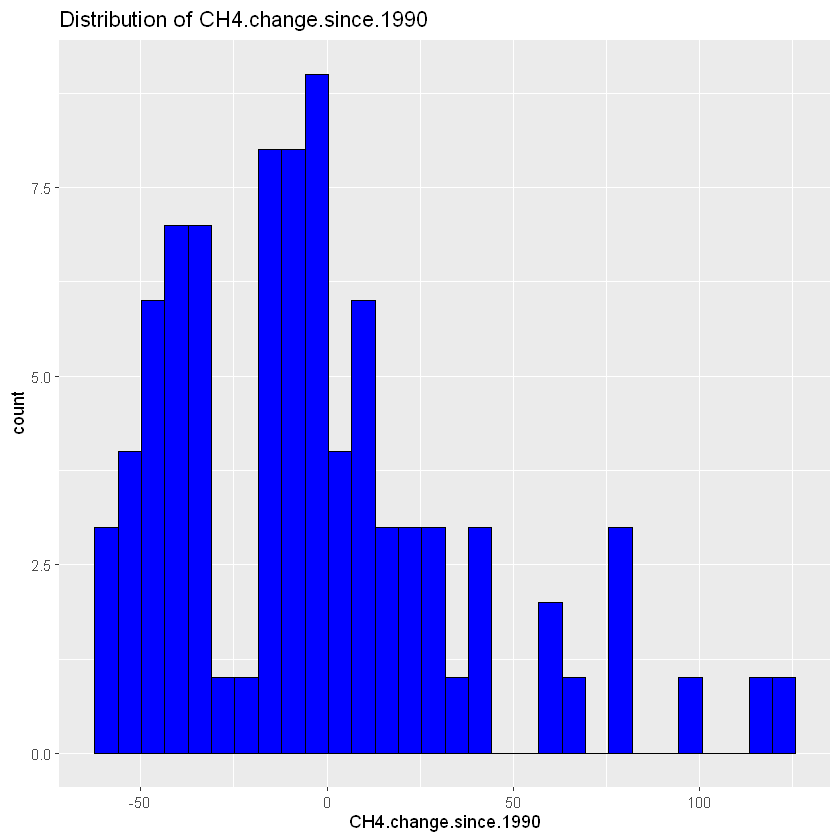

In [473]:
library(ggplot2)

ggplot(df, aes(x = CH4.change.since.1990)) +
  geom_histogram(bins = 30, fill = "blue", color = "black", na.rm= TRUE) +
  ggtitle("Distribution of CH4.change.since.1990")

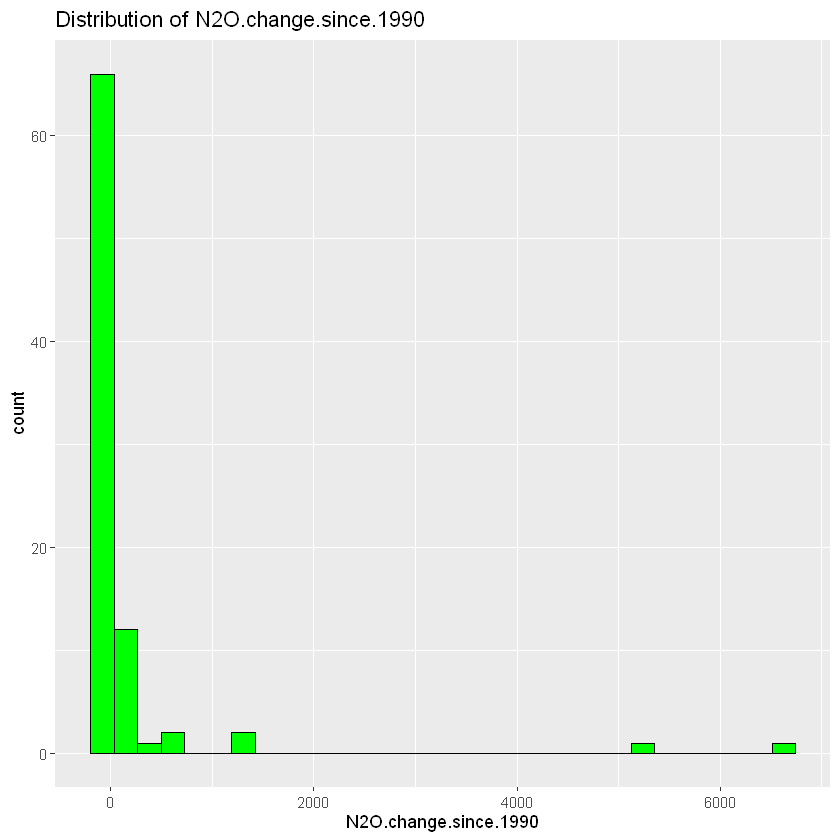

In [474]:
ggplot(df, aes(x = N2O.change.since.1990)) +
  geom_histogram(bins = 30, fill = "green", color = "black", na.rm=TRUE) +
  ggtitle("Distribution of N2O.change.since.1990")

In [475]:
#type2 skewness = sample statistics
library(e1071)
skew_chg = skewness(df$CH4.change.since.1990, na.rm = TRUE, type = 2)
skew_chg

[1] 1.020843

In [476]:
skew_chg.1 = skewness(df$N2O.change.since.1990, na.rm = TRUE, type = 2)
skew_chg.1

[1] 6.011556

In [477]:
#Due to outliers, median is suitable
mdn.CH4Change <- median(df$CH4.change.since.1990, na.rm = TRUE)
df$CH4.change.since.1990[is.na(df$CH4.change.since.1990)] <- mdn.CH4Change

In [478]:
#Due to outliers, median is suitable
mdn.N2OChange <- median(df$N2O.change.since.1990, na.rm = TRUE)
df$N2O.change.since.1990[is.na(df$N2O.change.since.1990)] <- mdn.N2OChange

In [479]:
#Transformation due to extreme skewness ""
df$CH4.change.since.1990 <- sign(df$CH4.change.since.1990) * (abs(df$CH4.change.since.1990)^(1/3))

In [480]:
skewness(df$N2O.change.since.1990, na.rm = TRUE)

[1] 8.797157

In [481]:
#Validating the data
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                        0                        0 
CH4.emissions.per.capita    CH4.change.since.1990            N2O.emissions 
                       0                        0                        0 
N2O.emissions.per.capita    N2O.change.since.1990 
                       0                        0

In [482]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,-1.916114,5.94,0.24,-12.08
Albania,1994,2.14,0.68,-1.916114,0.29,0.09,-12.08
Algeria,2000,32.92,1.06,-1.916114,6.50,0.21,-12.08
Angola,2005,19.93,1.11,-1.916114,13.87,0.77,-12.08
Antigua and Barbuda,2000,0.14,1.83,3.523381,0.08,1.08,5197.47
Argentina,2000,84.85,2.29,2.189760,67.50,1.82,30.26
Armenia,2010,2.26,0.76,-3.060263,0.48,0.16,185.46
Australia,2012,111.71,4.88,-1.445447,25.78,1.13,40.43
Austria,2012,5.31,0.63,-3.311682,5.22,0.62,-15.75


In [483]:
glimpse(df)

Rows: 184
Columns: 8
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <dbl> 0.42, 0.68, 1.06, 1.11, 1.83, 2.29, 0.76, 4.8…
$ CH4.change.since.1990    <dbl> -1.916114, -1.916114, -1.916114, -1.916114, 3…
$ N2O.emissions            <dbl> 5.94, 0.29, 6.50, 13.87, 0.08, 67.50, 0.48, 2…
$ N2O.emissions.per.capita <dbl> 0.24, 0.09, 0.21, 0.77, 1.08, 1.82, 0.16, 1.1…
$ N2O.change.since.1990    <dbl> -12.08, -12.08, -12.08, -12.08, 5197.47, 30.2…


In [484]:
#Basic descriptive statistics
summary(df)

      Country    latest.year.available CH4.emissions    
 Length   :184   Min.   :1990          Min.   :  0.000  
 N.unique :184   1st Qu.:2000          1st Qu.:  1.290  
 N.blank  :  0   Median :2000          Median :  5.075  
 Min.nchar:  4   Mean   :2003          Mean   : 30.878  
 Max.nchar: 52   3rd Qu.:2010          3rd Qu.: 20.430  
                 Max.   :2012          Max.   :932.860  
 CH4.emissions.per.capita CH4.change.since.1990 N2O.emissions   
 Min.   :  0.0200         Min.   :-3.898        Min.   :  0.00  
 1st Qu.:  0.5475         1st Qu.:-1.916        1st Qu.:  0.45  
 Median :  0.8000         Median :-1.916        Median :  3.19  
 Mean   :  3.0856         Mean   :-1.271        Mean   : 17.04  
 3rd Qu.:  1.2950         3rd Qu.:-1.916        3rd Qu.: 11.93  
 Max.   :309.1000         Max.   : 4.969        Max.   :395.79  
 N2O.emissions.per.capita N2O.change.since.1990
 Min.   :  0.000          Min.   : -77.55      
 1st Qu.:  0.180          1st Qu.: -12.08      
 M

In [485]:
#tabular visualization for Methane emissions
df_stats<- df%>%
summarize(
    Mean = mean(CH4.emissions),
    Variance = var(CH4.emissions),
    Standard.Deviation = sd(CH4.emissions),
    No.Of.Observations = n()
  )
df_stats

Mean,Variance,Standard.Deviation,No.Of.Observations
<dbl>,<dbl>,<dbl>,<int>
30.87837,9454.304,97.23325,184


In [486]:
regional_summary<-df%>%group_by(Country) %>%
  summarize(
    Avg_Emission = mean(CH4.emissions)
  ) %>%
  arrange(desc(Avg_Emission))

print(regional_summary)

# A tibble: 184 × 2
   Country                  Avg_Emission
   <chr>                           <dbl>
 1 China                           933. 
 2 United States of America        552. 
 3 Russian Federation              503. 
 4 India                           407. 
 5 Brazil                          316. 
 6 Indonesia                       236. 
 7 Mexico                          188. 
 8 Australia                       112. 
 9 Canada                           90.6
10 Uzbekistan                       89.4
# ℹ 174 more rows


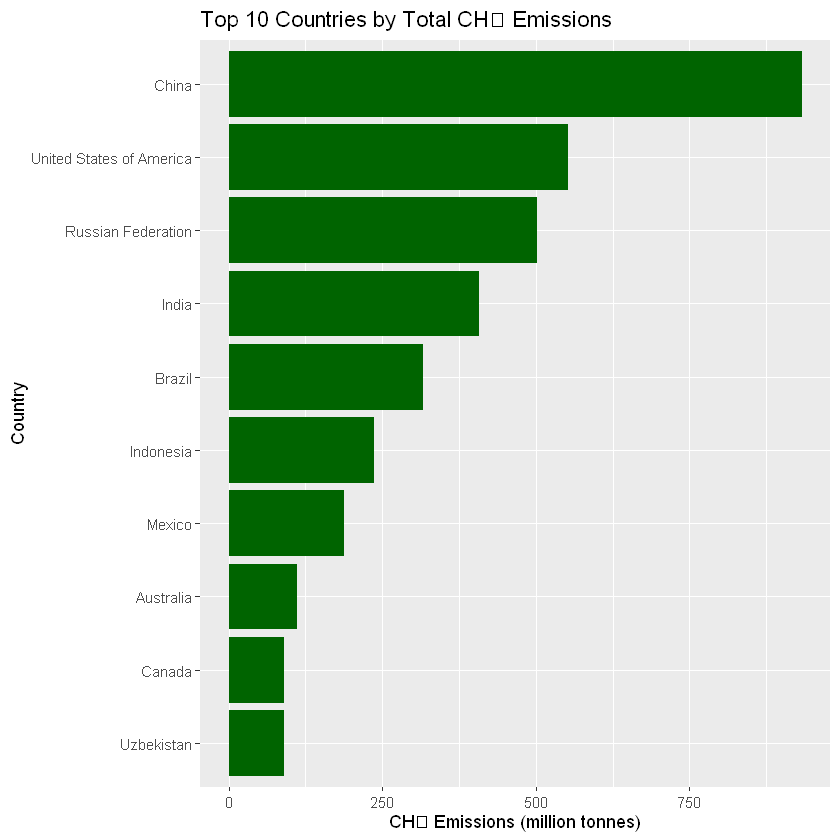

In [487]:
top_ch4 <- df %>% 
  arrange(desc(CH4.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, CH4.emissions), y = CH4.emissions)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total CH₄ Emissions",
       x = "Country", y = "CH₄ Emissions (million tonnes)")


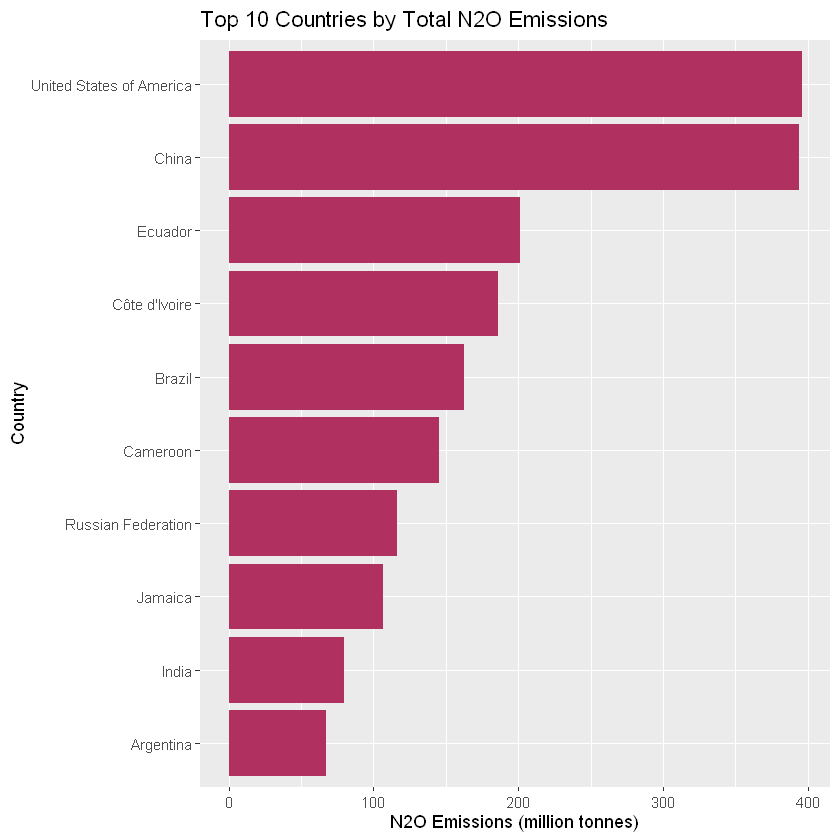

In [488]:
top_ch4 <- df %>% 
  arrange(desc(N2O.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, N2O.emissions), y = N2O.emissions)) +
  geom_bar(stat = "identity", fill = "maroon") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total N2O Emissions",
       x = "Country", y = "N2O Emissions (million tonnes)")


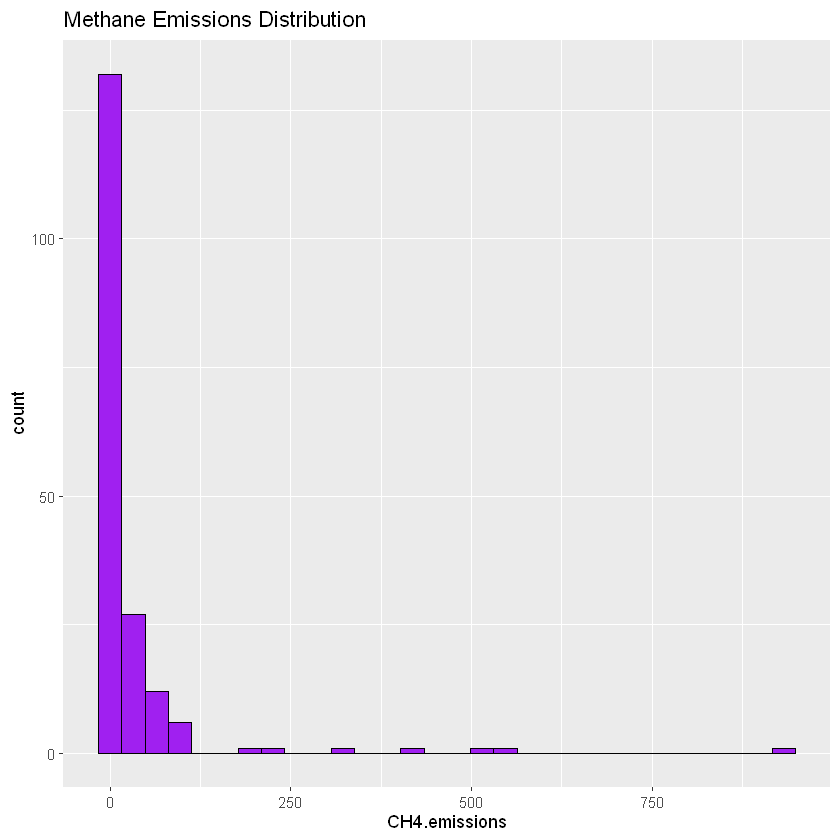

In [489]:
ggplot(df, aes(x = CH4.emissions)) +
  geom_histogram(bins = 30, fill = "purple", color = "black") +
  ggtitle("Methane Emissions Distribution")

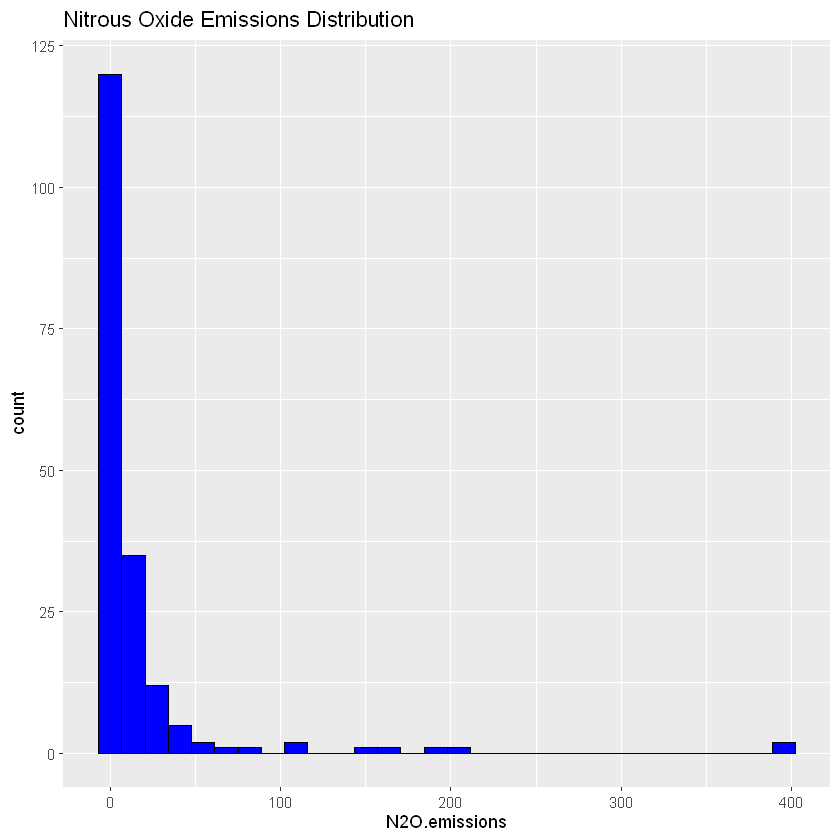

In [490]:
ggplot(df, aes(x = N2O.emissions)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  ggtitle("Nitrous Oxide Emissions Distribution")

In [491]:
#Feature Engineering , new variable
df$Total_Emissions <- df$CH4.emissions + df$N2O.emissions

In [492]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,Total_Emissions
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,-1.916114,5.94,0.24,-12.08,16.10
Albania,1994,2.14,0.68,-1.916114,0.29,0.09,-12.08,2.43
Algeria,2000,32.92,1.06,-1.916114,6.50,0.21,-12.08,39.42
Angola,2005,19.93,1.11,-1.916114,13.87,0.77,-12.08,33.80
Antigua and Barbuda,2000,0.14,1.83,3.523381,0.08,1.08,5197.47,0.22
Argentina,2000,84.85,2.29,2.189760,67.50,1.82,30.26,152.35


In [493]:
lowest_tot <- min(df$Total_Emissions, na.rm = TRUE)
highest_tot <- max(df$Total_Emissions, na.rm = TRUE)
print(lowest_tot )

[1] 0


In [494]:
print(highest_tot)

[1] 1326.96


In [495]:
df <- df %>%
  mutate(Methane_Safety = case_when(
    CH4.emissions >= 0.00 & CH4.emissions <=50  ~ "Safe",
    CH4.emissions >= 51 & CH4.emissions <= 950 ~ "Dangerous",
  ))

In [496]:
df <- df %>%
  mutate(Nitrous_Oxide_Safety = case_when(
    N2O.emissions >= 0.00 & N2O.emissions <= 18 ~ "Safe",
    N2O.emissions >=19  & N2O.emissions <= 400 ~ "Dangerous",
  ))

In [497]:
df <- df %>%
  mutate(Overall_Safety = case_when(
    Total_Emissions >= 0.00 & Total_Emissions <= 68 ~ "Safe",
    Total_Emissions >= 69 & Total_Emissions <= 1327.00 ~ "Dangerous",
  ))

In [498]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,Total_Emissions,Methane_Safety,Nitrous_Oxide_Safety,Overall_Safety
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Afghanistan,2005,10.16,0.42,-1.916114,5.94,0.24,-12.08,16.10,Safe,Safe,Safe
Albania,1994,2.14,0.68,-1.916114,0.29,0.09,-12.08,2.43,Safe,Safe,Safe
Algeria,2000,32.92,1.06,-1.916114,6.50,0.21,-12.08,39.42,Safe,Safe,Safe
Angola,2005,19.93,1.11,-1.916114,13.87,0.77,-12.08,33.80,Safe,Safe,Safe
Antigua and Barbuda,2000,0.14,1.83,3.523381,0.08,1.08,5197.47,0.22,Safe,Safe,Safe
Argentina,2000,84.85,2.29,2.189760,67.50,1.82,30.26,152.35,Dangerous,Dangerous,Dangerous
Armenia,2010,2.26,0.76,-3.060263,0.48,0.16,185.46,2.74,Safe,Safe,Safe
Australia,2012,111.71,4.88,-1.445447,25.78,1.13,40.43,137.49,Dangerous,Dangerous,Dangerous
Austria,2012,5.31,0.63,-3.311682,5.22,0.62,-15.75,10.53,Safe,Safe,Safe


In [499]:
# Feature Engineering: CH4 to N2O Ratio
df <- df %>%
  mutate(
    Emission_Ratio = CH4.emissions / (N2O.emissions + 0.0001),
    
    # Categorizing the profile based on the ratio
    Pollution_Profile = case_when(
      Emission_Ratio > 2 ~ "Methane-Dominant",
      Emission_Ratio < 0.5 ~ "Nitrous-Dominant",
      TRUE ~ "Balanced Profile"
    )
  )
  head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,Total_Emissions,Methane_Safety,Nitrous_Oxide_Safety,Overall_Safety,Emission_Ratio,Pollution_Profile
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
Afghanistan,2005,10.16,0.42,-1.916114,5.94,0.24,-12.08,16.10,Safe,Safe,Safe,1.710409,Balanced Profile
Albania,1994,2.14,0.68,-1.916114,0.29,0.09,-12.08,2.43,Safe,Safe,Safe,7.376767,Methane-Dominant
Algeria,2000,32.92,1.06,-1.916114,6.50,0.21,-12.08,39.42,Safe,Safe,Safe,5.064537,Methane-Dominant
Angola,2005,19.93,1.11,-1.916114,13.87,0.77,-12.08,33.80,Safe,Safe,Safe,1.436904,Balanced Profile
Antigua and Barbuda,2000,0.14,1.83,3.523381,0.08,1.08,5197.47,0.22,Safe,Safe,Safe,1.747815,Balanced Profile
Argentina,2000,84.85,2.29,2.189760,67.50,1.82,30.26,152.35,Dangerous,Dangerous,Dangerous,1.257035,Balanced Profile


In [500]:
# Feature Engineering: CH4 to N2O Ratio
df <- df %>%
  mutate(
    Emission_Ratio = CH4.emissions / (N2O.emissions + 0.0001),
    
    # Categorizing the profile based on the ratio
    Pollution_Profile = case_when(
      Emission_Ratio > 2 ~ "Methane-Dominant",
      Emission_Ratio < 0.5 ~ "Nitrous-Dominant",
      TRUE ~ "Balanced Profile"
    )
  )

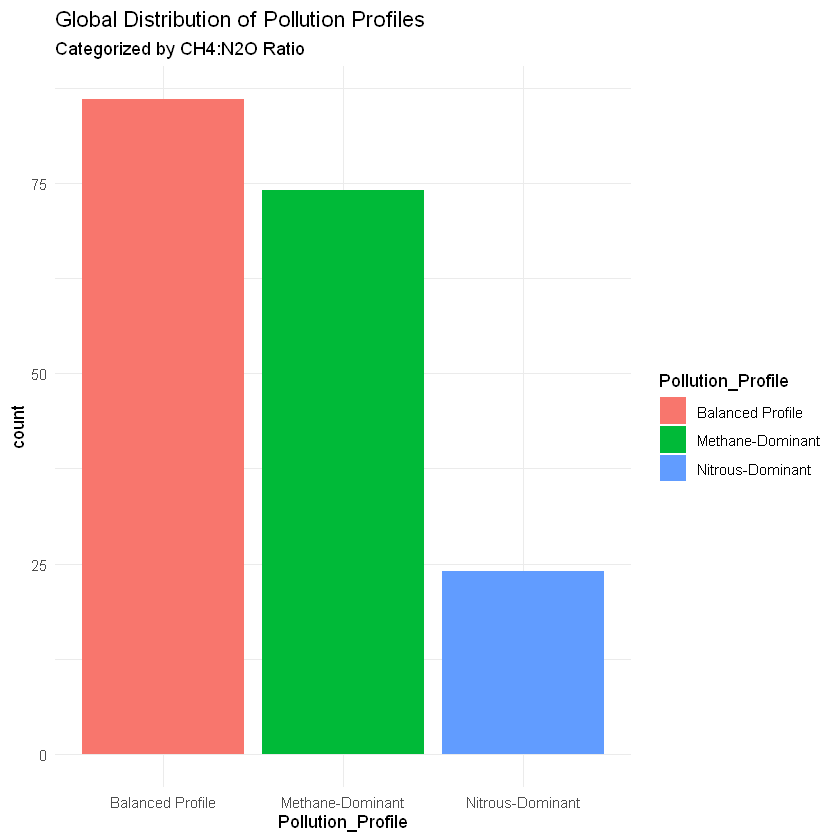

In [501]:
ggplot(df, aes(x = Pollution_Profile, fill = Pollution_Profile)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Global Distribution of Pollution Profiles",
       subtitle = "Categorized by CH4:N2O Ratio")

In [502]:
library(rnaturalearth)
library(sf)
world <- ne_countries(scale = "medium", returnclass = "sf")

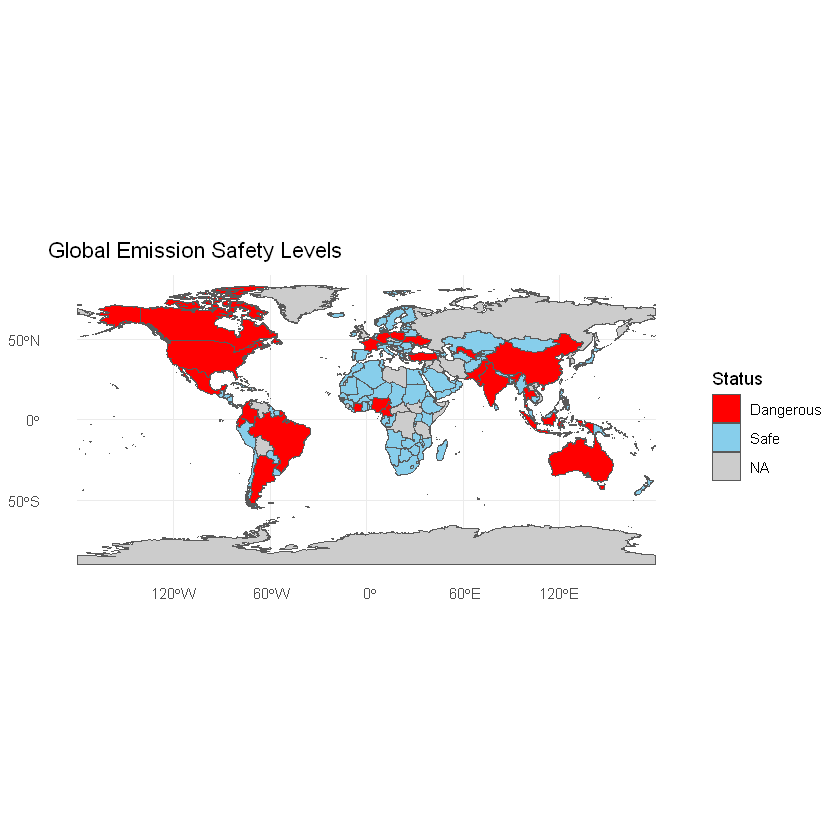

In [503]:
# Join the data
map_data <- left_join(world, df, by = c("name" = "Country"))

# Check if the column exists now
if(!"Overall_Safety" %in% colnames(map_data)) {
  stop("The column 'Overall_Safety' is missing from map_data. Check your join!")
}

#Plot with NA handling
ggplot(data = map_data) +
  geom_sf(aes(fill = Overall_Safety)) + 
  scale_fill_manual(values = c("Safe" = "skyblue", "Dangerous" = "red"), 
                    na.value = "grey80") + # Countries with no data will be grey
  theme_minimal() +
  labs(title = "Global Emission Safety Levels",
       fill = "Status")

In [504]:
# Create a vector of all names in your data that aren't on the map
missing_countries <- setdiff(df$Country, world$name)

# Display the full list
print(missing_countries)

 [1] "Antigua and Barbuda"                                 
 [2] "Bolivia (Plurinational State of)"                    
 [3] "Bosnia and Herzegovina"                              
 [4] "Central African Republic"                            
 [5] "Cook Islands"                                        
 [6] "Czech Republic"                                      
 [7] "Democratic People's Republic of Korea"               
 [8] "Democratic Republic of the Congo"                    
 [9] "Dominican Republic"                                  
[10] "Iran (Islamic Republic of)"                          
[11] "Lao People's Democratic Republic"                    
[12] "Micronesia (Federated States of)"                    
[13] "Republic of Korea"                                   
[14] "Republic of Moldova"                                 
[15] "Russian Federation"                                  
[16] "Saint Kitts and Nevis"                               
[17] "Saint Vincent and the Grenadines" 

In [505]:
#Identify which names in our data are missing from the map
mismatched_names <- setdiff(df$Country, world$name)

# Use 'stringdist' logic to find the closest match in the map library
# This creates a data frame showing your name vs. the map's closest suggestion
audit_table <- data.frame(
  Dataset_Name = mismatched_names,
  Suggested_Map_Name = sapply(mismatched_names, function(x) {
    # This finds the name in 'world' with the smallest spelling difference
    world$name[agrep(x, world$name, max.distance = 0.3, ignore.case = TRUE)][1]
  })
)

# 3. Display the result
print(audit_table)

                                                                                             Dataset_Name
Antigua and Barbuda                                                                   Antigua and Barbuda
Bolivia (Plurinational State of)                                         Bolivia (Plurinational State of)
Bosnia and Herzegovina                                                             Bosnia and Herzegovina
Central African Republic                                                         Central African Republic
Cook Islands                                                                                 Cook Islands
Czech Republic                                                                             Czech Republic
Democratic People's Republic of Korea                               Democratic People's Republic of Korea
Democratic Republic of the Congo                                         Democratic Republic of the Congo
Dominican Republic                            

In [506]:
#Clean whitespace first
df$Country <- trimws(df$Country)

#Match names to the rnaturalearth "world" library
df <- df %>%
  mutate(Country = recode(Country, 
    "Antigua and Barbuda" = "Antigua and Barb.",
    "Bolivia (Plurinational State of)" = "Bolivia",
    "Bosnia and Herzegovina" = "Bosnia and Herz.",
    "Central African Republic" = "Central African Rep.",
    "Cook Islands" = "Cook Is.",
    "Czech Republic" = "Czechia",
    "Democratic People's Republic of Korea" = "North Korea",
    "Democratic Republic of the Congo" = "Dem. Rep. Congo",
    "Dominican Republic" = "Dominican Rep.",
    "Iran (Islamic Republic of)" = "Iran",
    "Lao People's Democratic Republic" = "Laos",
    "Micronesia (Federated States of)" = "Micronesia",
    "Republic of Korea" = "South Korea",
    "Republic of Moldova" = "Moldova",
    "Russian Federation" = "Russia",
    "Saint Kitts and Nevis" = "St. Kitts and Nevis",
    "Saint Vincent and the Grenadines" = "St. Vin. and Gren.",
    "Sao Tome and Principe" = "São Tomé and Principe",
    "Swaziland" = "eSwatini",
    "The former Yugoslav Republic of Macedonia" = "North Macedonia",
    "United Kingdom of Great Britain and Northern Ireland" = "United Kingdom",
    "United Republic of Tanzania" = "Tanzania",
    "Venezuela (Bolivarian Republic of)" = "Venezuela",
    "Viet Nam" = "Vietnam"
  ))

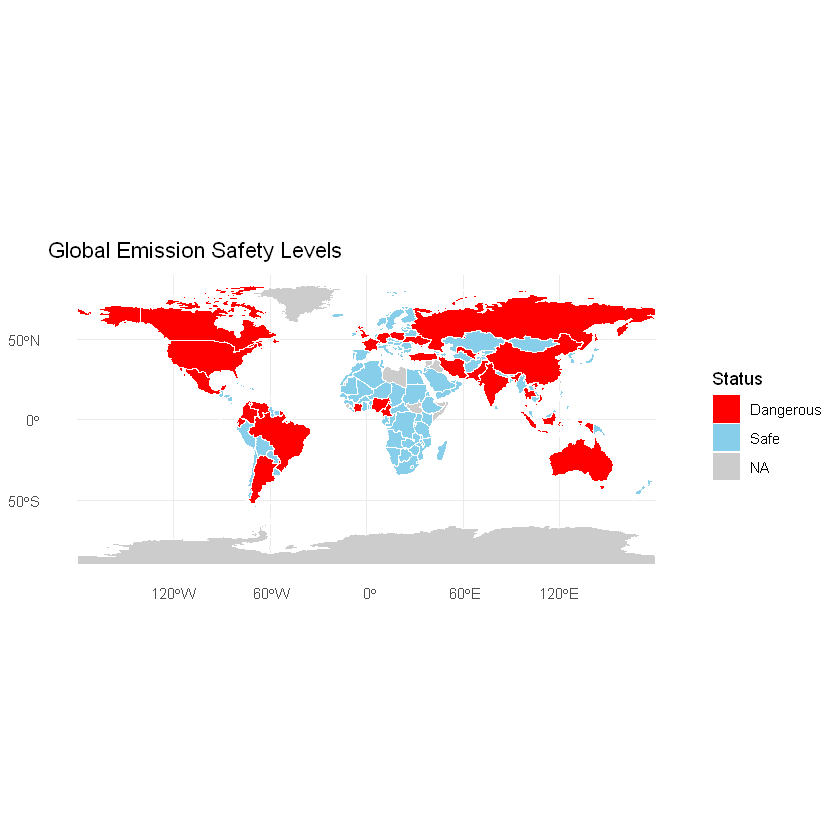

In [507]:
# Join
map_data <- left_join(world, df, by = c("name" = "Country"))

# Plot
ggplot(data = map_data) +
  geom_sf(aes(fill = Overall_Safety), color = "white", size = 0.1) + 
  scale_fill_manual(
    values = c("Safe" = "skyblue", "Dangerous" = "red"), 
    na.value = "grey80"
  ) + 
  theme_minimal() +
  labs(title = "Global Emission Safety Levels", fill = "Status")

**Distribution: Histogram**

In [508]:
# 1. Create a clean version of the data that removes 0s and NAs
# (This prevents log10(0) from turning into infinity)
df_clean <- df %>%
  filter(CH4.emissions > 0, N2O.emissions > 0) %>%
  drop_na(CH4.emissions, N2O.emissions)

# 2. Calculate the Correlation Coefficient on the clean data
correlation_r <- cor(log10(df_clean$CH4.emissions), log10(df_clean$N2O.emissions), use = "complete.obs")

# 3. Create the Scatterplot using df_clean
ggplot(df_clean, aes(x = CH4.emissions, y = N2O.emissions)) +
  geom_point(aes(color = Region), alpha = 0.7, size = 2.5) +  
  geom_smooth(method = "lm", color = "black", se = TRUE, linetype = "dashed") + 
  scale_x_log10() + scale_y_log10() + 
  theme_minimal() +
  labs(
    title = "Relationship between CH₄ and N₂O Emissions",
    subtitle = paste("Logarithmic scale applied. Pearson r (log-transformed) =", round(correlation_r, 3)),
    x = "Methane (CH₄) Emissions (Log 10 Scale)",
    y = "Nitrous Oxide (N₂O) Emissions (Log 10 Scale)",
    color = "World Region"
  )

ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'Region' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .

***REPETION***

Warning message:
"Removed 3 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


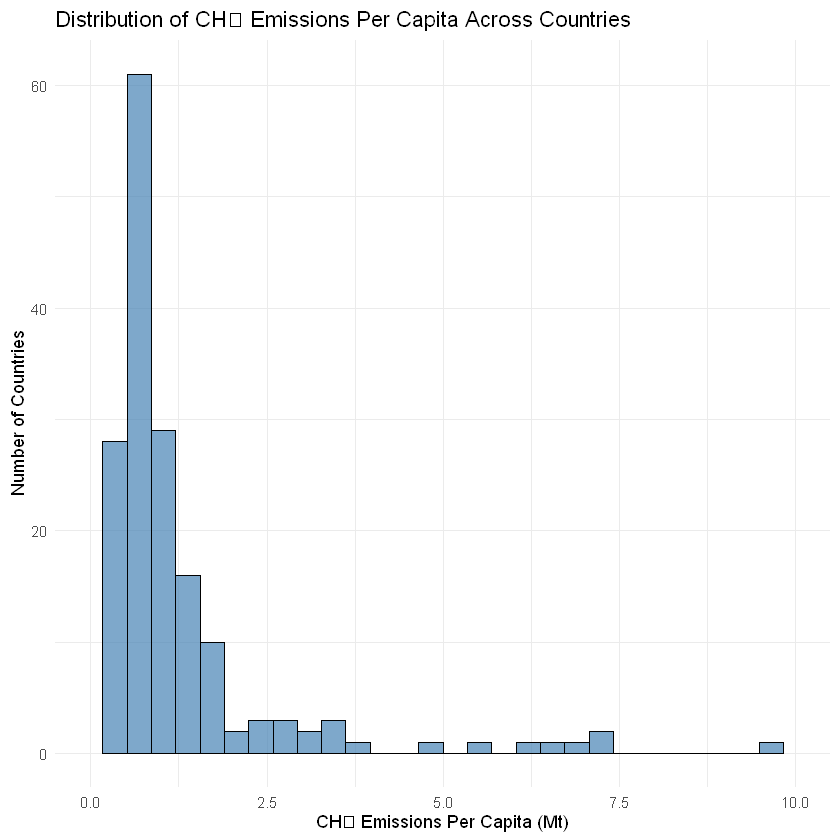

In [509]:
# Histogram of CH4 per capita (all countries)
ggplot(df, aes(x = CH4.emissions.per.capita)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
  labs(
    title = "Distribution of CH₄ Emissions Per Capita Across Countries",
    x = "CH₄ Emissions Per Capita (Mt)",
    y = "Number of Countries"
  ) +
  theme_minimal() +
  xlim(0, 10)  # Excludes extreme outliers like Greece error

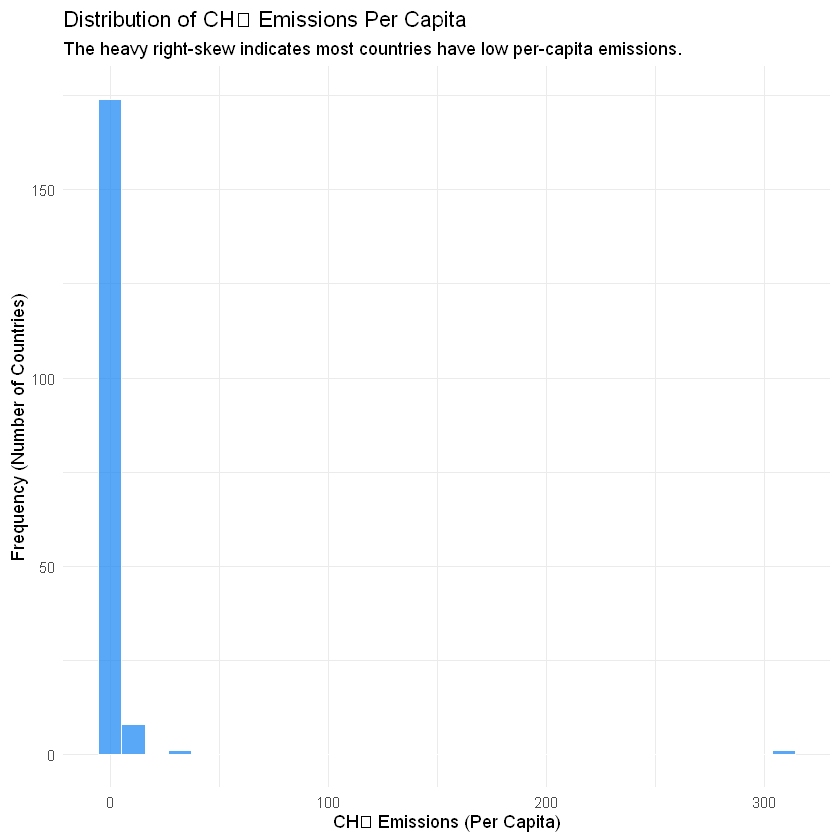

In [510]:
# 1. DISTRIBUTION (Histogram)
# Exploring the distribution of CH4 Emissions Per Capita
ggplot(df, aes(x = CH4.emissions.per.capita)) +
  geom_histogram(bins = 30, fill = "#1182f3", color = "white", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Distribution of CH₄ Emissions Per Capita",
       subtitle = "The heavy right-skew indicates most countries have low per-capita emissions.",
       x = "CH₄ Emissions (Per Capita)",
       y = "Frequency (Number of Countries)")

Warning message:
"Removed 8 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


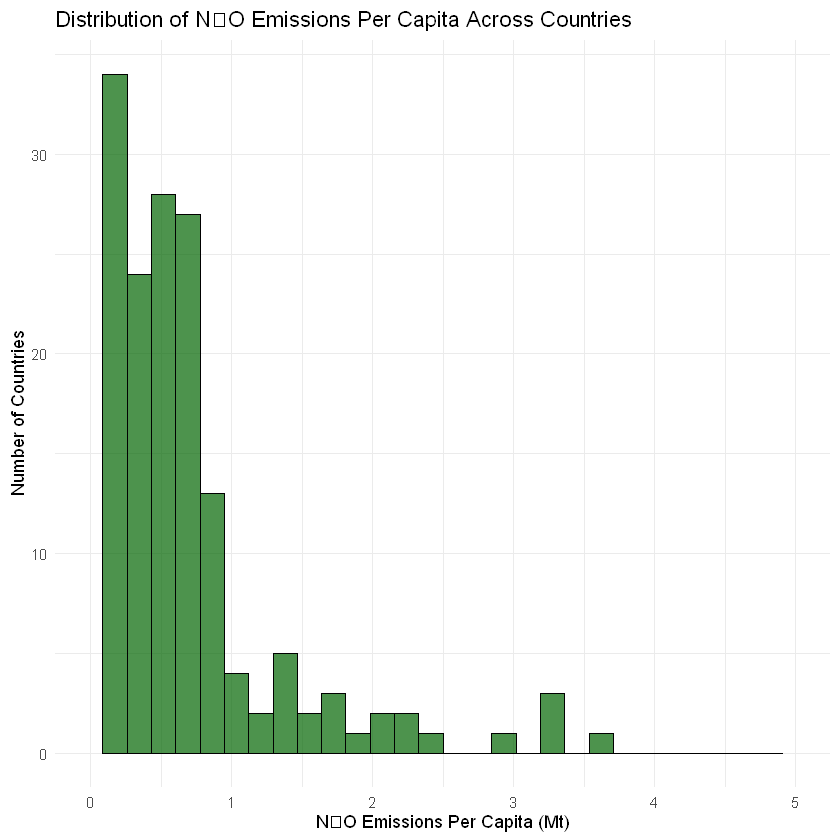

In [511]:
# Histogram of N2O per capita
ggplot(df, aes(x = N2O.emissions.per.capita)) +
  geom_histogram(bins = 30, fill = "darkgreen", color = "black", alpha = 0.7) +
  labs(
    title = "Distribution of N₂O Emissions Per Capita Across Countries",
    x = "N₂O Emissions Per Capita (Mt)",
    y = "Number of Countries"
  ) +
  theme_minimal() +
  xlim(0, 5)  # Adjust as needed

**Relationship: Scatter Plot**

In [512]:
# 2. RELATIONSHIP (Scatter Plot)
# Investigating the correlation between Methane and Nitrous Oxide emissions
ggplot(df, aes(x = CH4.emissions, y = N2O.emissions, color = Region)) +
  geom_point(alpha = 0.7, size = 2.5) +
  scale_x_log10() + scale_y_log10() + # Log transformation applied to handle extreme outliers
  theme_minimal() +
  labs(title = "Relationship: CH₄ vs. N₂O Total Emissions",
       subtitle = "Logarithmic scale applied to reveal the linear correlation hidden by massive outliers.",
       x = "CH₄ Emissions (Log 10 Scale)",
       y = "N₂O Emissions (Log 10 Scale)",
       color = "World Region")

ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'Region' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .

**Trend: Line Chart**

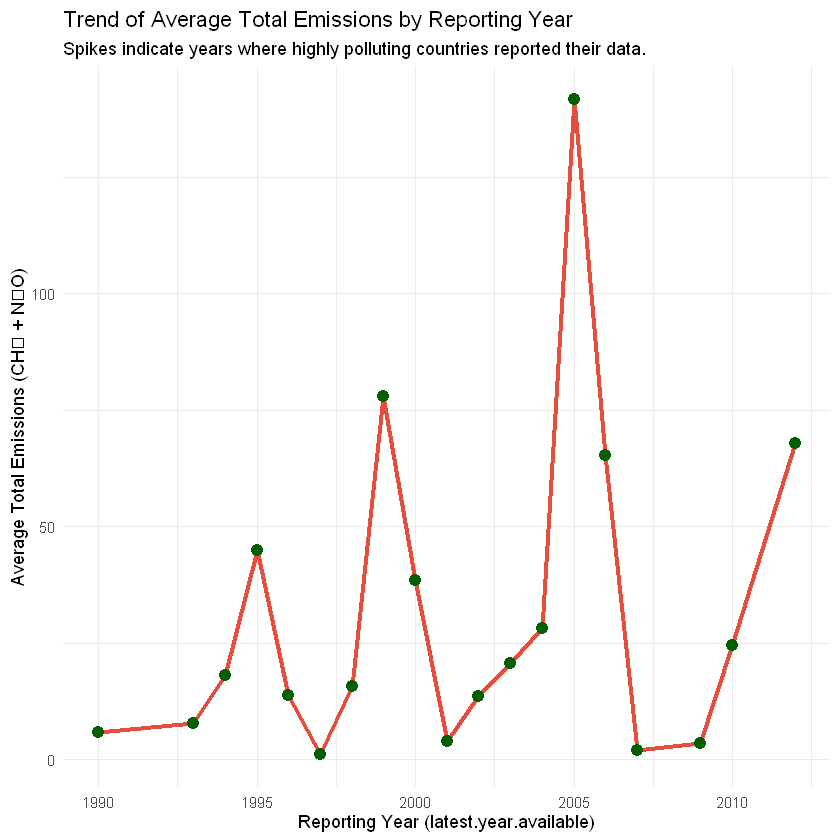

In [513]:
# 3. TREND (Line Chart)
# Tracking how average total emissions look based on the reporting year
df %>%
  group_by(latest.year.available) %>%
  summarize(Avg_Total = mean(Total_Emissions, na.rm = TRUE)) %>%
  drop_na() %>%
  ggplot(aes(x = latest.year.available, y = Avg_Total)) +
  geom_line(color = "#E74C3C", size = 1.2) +
  geom_point(color = "#045e02", size = 3) +
  theme_minimal() +
  labs(title = "Trend of Average Total Emissions by Reporting Year",
       subtitle = "Spikes indicate years where highly polluting countries reported their data.",
       x = "Reporting Year (latest.year.available)",
       y = "Average Total Emissions (CH₄ + N₂O)")

**Strategy Comparison: Bar vs. Boxplot**

In [514]:
# 4. COMPARING STRATEGIES (Bar Chart vs. Boxplot)

# Strategy A: Bar Chart (Averages)
p1 <- df %>%
  group_by(Region) %>%
  summarize(Avg_Total = mean(Total_Emissions, na.rm=TRUE)) %>%
  drop_na() %>%
  ggplot(aes(x = reorder(Region, Avg_Total), y = Avg_Total, fill = Region)) +
  geom_col(alpha = 0.8) +
  coord_flip() +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "Strategy A: Average Emissions (Bar)", x = "", y = "Mean Total Emissions")

# Strategy B: Boxplot (Distribution)
p2 <- df %>% drop_na(Region) %>%
  ggplot(aes(x = reorder(Region, Total_Emissions, FUN=median, na.rm=TRUE), y = Total_Emissions, fill = Region)) +
  geom_boxplot(alpha = 0.8) +
  scale_y_log10() + 
  coord_flip() +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "Strategy B: Emission Spread (Boxplot)", x = "", y = "Total Emissions (Log Scale)")

# Display side-by-side using the patchwork library (install.packages("patchwork") if needed)
library(patchwork)
p1 + p2

ERROR: [1m[33mError[39m in `group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `Region` is not found.


***Deliverable 2: Design Justification***
 * To ensure our visualizations effectively communicate the data without causing cognitive overload, we applied the following design principles:
* **High Data-to-Ink Ratio:** We utilized `theme_minimal()` across all charts. By removing heavy grid lines, axis borders, and grey backgrounds, the focus remains entirely on the data points.
* **Appropriate Scaling for Perception:** Environmental data is heavily skewed by a few massive outlier countries (e.g., USA, China). Using a standard linear scale clusters 95% of the data into a single unreadable point. By applying logarithmic scales (`scale_x_log10`, `scale_y_log10`), we respected human perception limits and revealed the hidden relationships among lower-emitting countries.
* **Strategic Opacity:** In the scatter plot, we used `alpha = 0.7`. This prevents "overplotting" (where solid points hide data underneath them) and allows us to clearly see where countries densely cluster.
* **Comparison of Strategies:** We compared a Bar Chart (Strategy A) to a Boxplot (Strategy B). The Bar Chart is flawed here: it uses the mean, which is heavily distorted by extreme outliers, making certain regions look uniformly terrible. Strategy B (the Boxplot on a log scale) is a superior choice for this data, as it accurately displays the median and highlights that most countries within a region are actually clustered lower, with a few extreme outliers driving up the regional average.

### Deliverable 3: Insight Analysis Report
Based on our exploratory visual analysis, we extracted the following key insights:
1. **The Methane/Nitrous Oxide Correlation:** Our scatter plot reveals a strict, positive correlation between CH₄ and N₂O emissions. Countries do not typically emit high levels of one without the other. This suggests that the industrial, agricultural, or economic drivers behind these two greenhouse gases are deeply intertwined. 
2. **The "Outlier" Reality of Global Emissions:** The histogram of per-capita emissions, combined with our regional boxplots, confirms that the vast majority of countries are low-emitters. Global averages are almost entirely dictated by a handful of extreme outlier countries. 
3. **Reporting Year Volatility:** The line chart tracking average emissions by reporting year shows significant volatility. Because different countries report in different years, "spikes" in the trend line likely align with the years that the heaviest polluters submitted their data, rather than a sudden global spike in actual physical emissions. This is a critical data bias we must account for in our future statistical modeling.

***MILESTONE 4***

In [515]:
# Correlation between CH₄ and N₂O per capita
cor(df$CH4.emissions.per.capita, df$N2O.emissions.per.capita, use = "complete.obs")

# Correlation matrix of all numeric variables
numeric_vars <- df[, c("CH4.emissions.per.capita", "N2O.emissions.per.capita", 
                       "CH4.change.since.1990", "N2O.change.since.1990", 
                       "Total_Emissions")]
cor(numeric_vars, use = "complete.obs")

[1] -0.0074534

,CH4.emissions.per.capita,N2O.emissions.per.capita,CH4.change.since.1990,N2O.change.since.1990,Total_Emissions
CH4.emissions.per.capita,1.00000000,-0.007453400,-0.02079541,-0.013189130,-0.01490175
N2O.emissions.per.capita,-0.00745340,1.000000000,0.18341522,-0.005628708,0.11357068
CH4.change.since.1990,-0.02079541,0.183415219,1.00000000,0.143740543,0.07289593
N2O.change.since.1990,-0.01318913,-0.005628708,0.14374054,1.000000000,-0.03804912
Total_Emissions,-0.01490175,0.113570679,0.07289593,-0.038049121,1.00000000


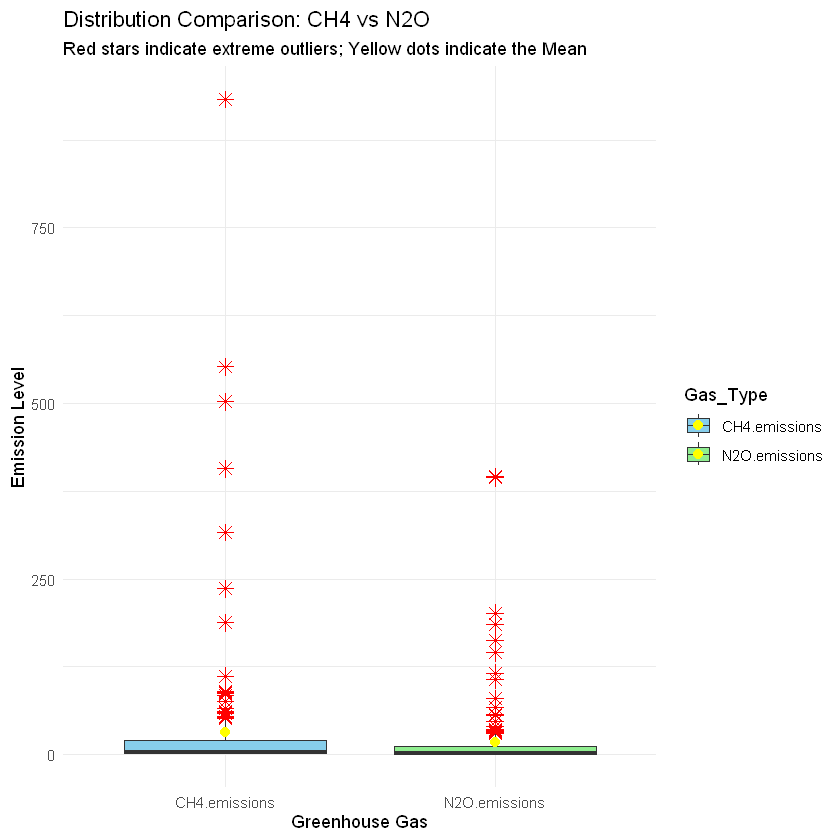

In [516]:
#Reshape data 
df_long <- df %>%
  pivot_longer(cols = c(CH4.emissions, N2O.emissions), 
               names_to = "Gas_Type", 
               values_to = "Emissions")


ggplot(df_long, aes(x = Gas_Type, y = Emissions, fill = Gas_Type)) +
  geom_boxplot(outlier.colour = "red", outlier.shape = 8, outlier.size = 3) +
  stat_summary(fun = mean, geom = "point", shape = 20, size = 4, color = "yellow") +
  scale_fill_manual(values = c("skyblue", "lightgreen")) +
  theme_minimal() +
  labs(
    title = "Distribution Comparison: CH4 vs N2O",
    subtitle = "Red stars indicate extreme outliers; Yellow dots indicate the Mean",
    x = "Greenhouse Gas",
    y = "Emission Level"
  )

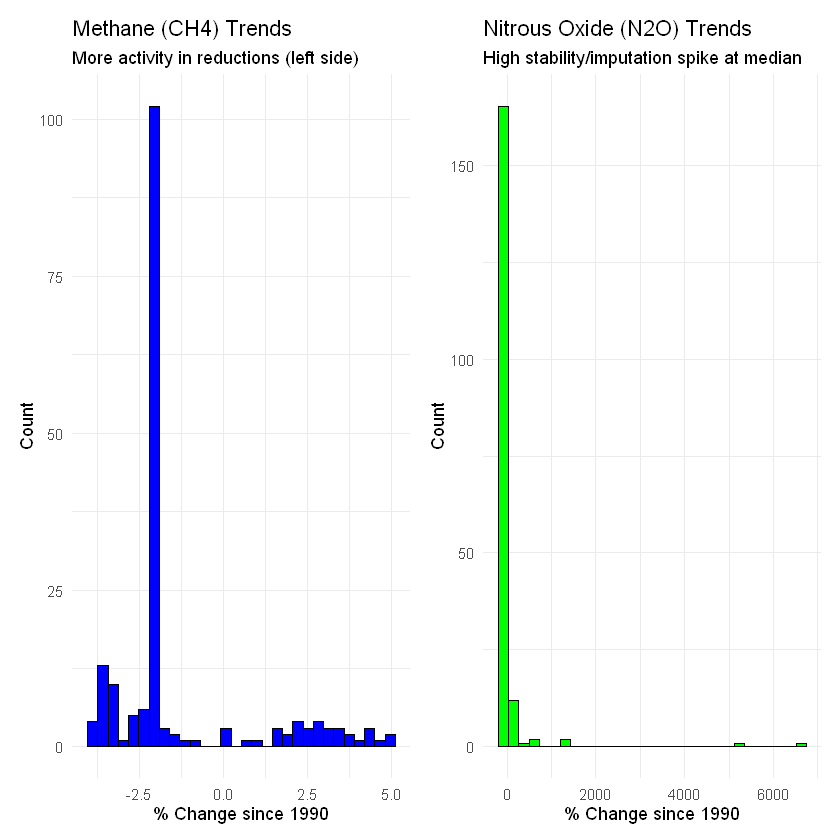

In [517]:
library(patchwork)


p1 <- ggplot(df, aes(x = CH4.change.since.1990)) +
  geom_histogram(bins = 30, fill = "blue", color = "black", na.rm = TRUE) +
  theme_minimal() +
  labs(title = "Methane (CH4) Trends",
       subtitle = "More activity in reductions (left side)",
       x = "% Change since 1990", y = "Count")


p2 <- ggplot(df, aes(x = N2O.change.since.1990)) +
  geom_histogram(bins = 30, fill = "green", color = "black", na.rm = TRUE) +
  theme_minimal() +
  labs(title = "Nitrous Oxide (N2O) Trends",
       subtitle = "High stability/imputation spike at median",
       x = "% Change since 1990", y = "Count")

combined_plot <- p1 + p2

combined_plot


ggsave("Emissions_Comparison_Milestone3.png", plot = combined_plot, width = 12, height = 6)


In [518]:
# Independent T-test
#Do "Dangerous" methane emitters also have significantly higher N2O emissions on average compared to "Safe" ones?
t_test_result <- t.test(N2O.emissions ~ Methane_Safety, data = df)
print(t_test_result)


	Welch Two Sample t-test

data:  N2O.emissions by Methane_Safety
t = 2.7372, df = 22.363, p-value = 0.01192
alternative hypothesis: true difference in means between group Dangerous and group Safe is not equal to 0
95 percent confidence interval:
  15.13289 109.39649
sample estimates:
mean in group Dangerous      mean in group Safe 
              71.523913                9.259221 



In [519]:
# Create a contingency table
table_data <- table(df$Methane_Safety, df$Pollution_Profile)

# Run Chi-Square
chi_sq <- chisq.test(table_data)
print(chi_sq)

Warning message in chisq.test(table_data):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  table_data
X-squared = 8.3175, df = 2, p-value = 0.01563



In [ ]:

fisher.test(table_data)  # Used when the table is small

chisq.test(table_data, simulate.p.value = TRUE, B = 2000)  # Used when the table is large.


	Fisher's Exact Test for Count Data

data:  table_data
p-value = 0.01325
alternative hypothesis: two.sided



	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  table_data
X-squared = 8.3175, df = NA, p-value = 0.01449


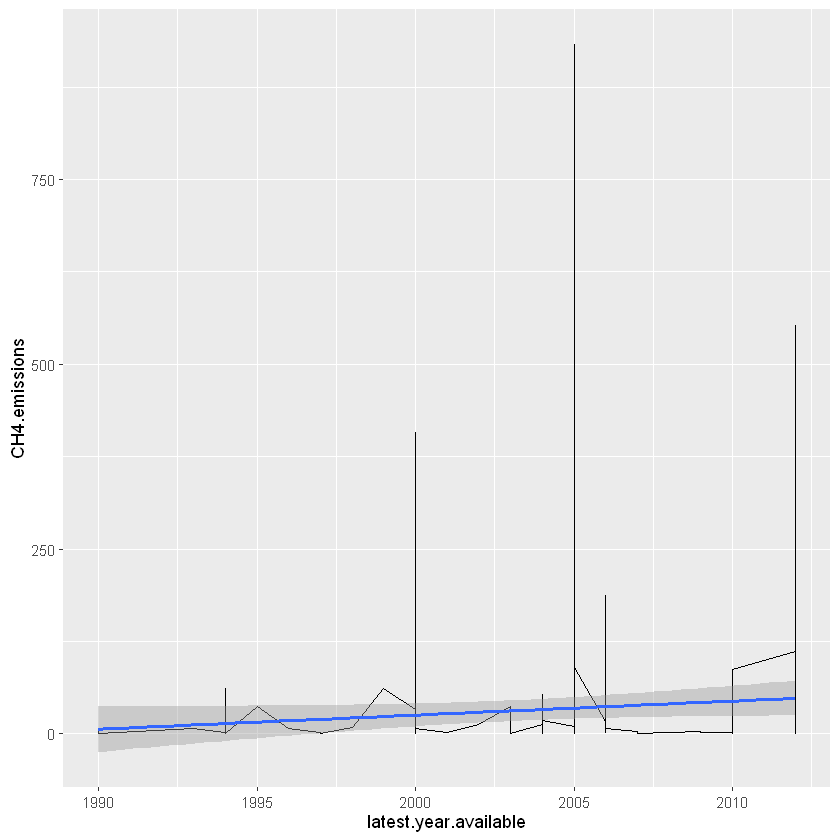

In [521]:
# Simple Trend Model
trend_model <- lm(CH4.emissions ~ latest.year.available,data = df)
# Plotting the trend
ggplot(df, aes(x=latest.year.available, y=CH4.emissions)) + geom_line() + geom_smooth(method="lm", formula = y ~ x)

***CHANGES MADE FROM MILESTONE ONE***
* **Milestone Appendix: Documented Changes**
* *Change 1: Skewness Calculation*

* What changed: We changed our skewness calculation from using the population mean to the sample mean.

* What failed: The standard calculation for skewness treats the dataset as a full population. Using this method did not give us an unbiased sample estimation.

* Why it failed: Our data is essentially a sample of environmental tracking, so using the standard population-level formula is statistically inappropriate and yields slightly inaccurate descriptive statistics for a sample.

* Alternative solution: We installed and imported the e1071 library and applied the skewness() function using the type = 2 parameter, which correctly calculates the sample moment.

* *Change 2: Data Transformation Strategy*

* What changed: We moved from using a log transformation to a cubic root transformation.

* What failed: Attempting to apply a standard logarithmic transformation (like log10()) threw mathematical errors and generated NaN (Not a Number) values, which ruined the dataset structure.

* Why it failed: The specific columns we are analyzing (CH4.change.since.1990 and N2O.change.since.1990) represent percentage changes. Many countries have successfully reduced their emissions, resulting in negative values. It is mathematically impossible to calculate the logarithm of a negative number.

* Alternative solution: We implemented a signed cubic root transformation using the formula sign(x) * (abs(x)^(1/3)). This alternative safely handles both positive and negative numbers while still effectively compressing the extreme outliers to fix the data's right-skewness.